In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.impute import SimpleImputer

In [ ]:
df0 = pd.read_csv("0.csv")
df1 = pd.read_csv("1.csv")
df2 = pd.read_csv("2.csv")
df3 = pd.read_csv("3.csv")

# Assign labels
df0['label'] = 0
df1['label'] = 1
df2['label'] = 2
df3['label'] = 3

# Merge (DO NOT shuffle here)
df = pd.concat([df0, df1, df2, df3], ignore_index=True)

df.head()

,26.0,4.0,5.0,8.0,-1.0,-13.0,-109.0,-66.0,-9.0,2.0,...,-29.0,0.0.3,7.0.1,7.0.2,-15.0.1,-6.0.3,25.0,1.0.5,1.0.6,3
0,-47.0,-6.0,-5.0,-7.0,13.0,-1.0,35.0,-10.0,10.0,-4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,-19.0,-8.0,-8.0,-8.0,-21.0,-6.0,-79.0,12.0,0.0,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2.0,3.0,0.0,2.0,0.0,22.0,106.0,-14.0,-16.0,-2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,6.0,0.0,0.0,-2.0,-14.0,10.0,-51.0,5.0,7.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,15.0,-5.0,-5.0,-15.0,12.0,-22.0,-38.0,36.0,9.0,6.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Drop unwanted column if exists
if 'Id' in df.columns:
    df = df.drop(columns=['Id'])

# Split features & target
X = df.drop('label', axis=1)
y = df['label']

# Convert to numeric (handles hidden errors)
X = X.apply(pd.to_numeric, errors='coerce')

# Handle NaN values properly
imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)

# Safety check
print("Remaining NaNs:", np.isnan(X).sum())

Remaining NaNs: 0


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("NaNs after scaling:", np.isnan(X_train).sum())

NaNs after scaling: 0


In [ ]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Random Forest
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# SVM
svm = SVC(kernel='linear')
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

# KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

# Decision Tree
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

In [ ]:
def evaluate(y_test, y_pred, name):
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))

evaluate(y_test, y_pred_lr, "Logistic Regression")
evaluate(y_test, y_pred_rf, "Random Forest")
evaluate(y_test, y_pred_svm, "SVM")
evaluate(y_test, y_pred_knn, "KNN")
evaluate(y_test, y_pred_dt, "Decision Tree")


Logistic Regression
Accuracy: 0.36616702355460384
              precision    recall  f1-score   support

           0       0.40      0.35      0.37       582
           1       0.41      0.34      0.37       580
           2       0.33      0.37      0.35       589
           3       0.35      0.41      0.38       584

    accuracy                           0.37      2335
   macro avg       0.37      0.37      0.37      2335
weighted avg       0.37      0.37      0.37      2335


Random Forest
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       582
           1       1.00      1.00      1.00       580
           2       1.00      1.00      1.00       589
           3       1.00      1.00      1.00       584

    accuracy                           1.00      2335
   macro avg       1.00      1.00      1.00      2335
weighted avg       1.00      1.00      1.00      2335


SVM
Accuracy: 0.4004282655246253
              pr

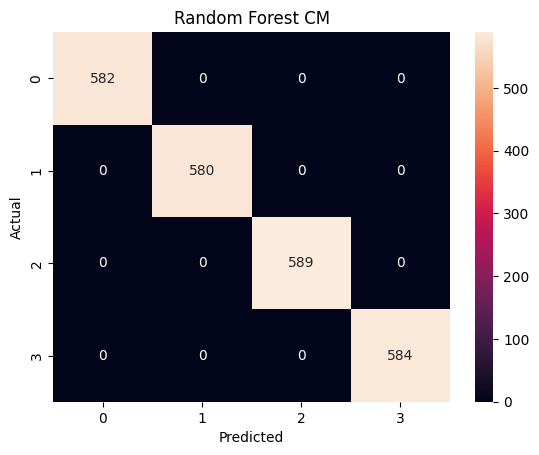

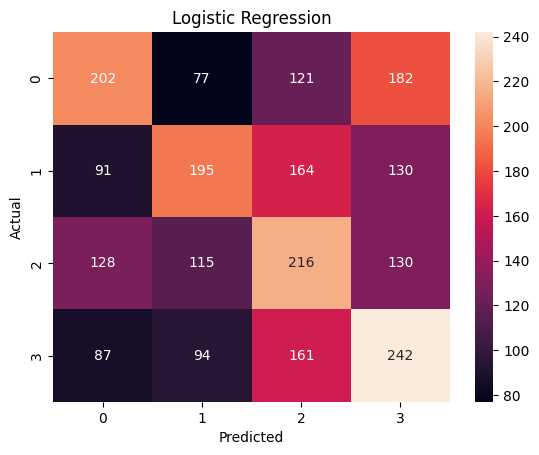

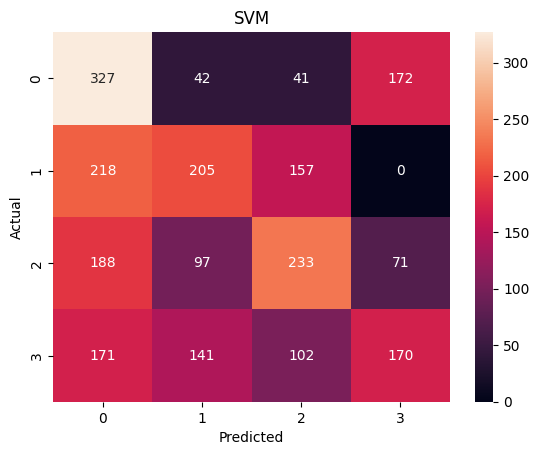

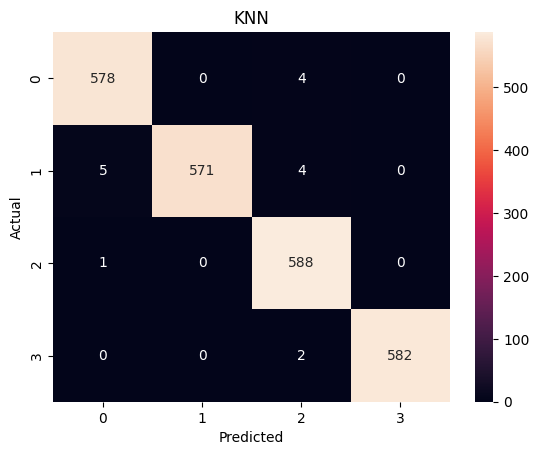

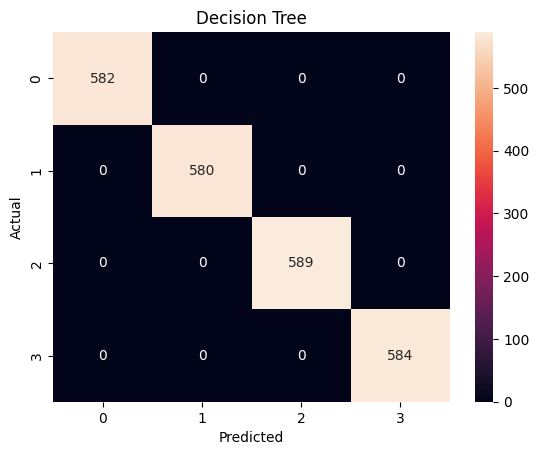

In [ ]:
def plot_cm(y_test, y_pred, title):
    cm = confusion_matrix(y_test, y_pred)
    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

plot_cm(y_test, y_pred_rf, "Random Forest CM")
plot_cm(y_test, y_pred_lr, "Logistic Regression")
plot_cm(y_test, y_pred_svm, "SVM")
plot_cm(y_test, y_pred_knn, "KNN")
plot_cm(y_test, y_pred_dt, "Decision Tree")

Text(0, 0.5, 'Accuracy')

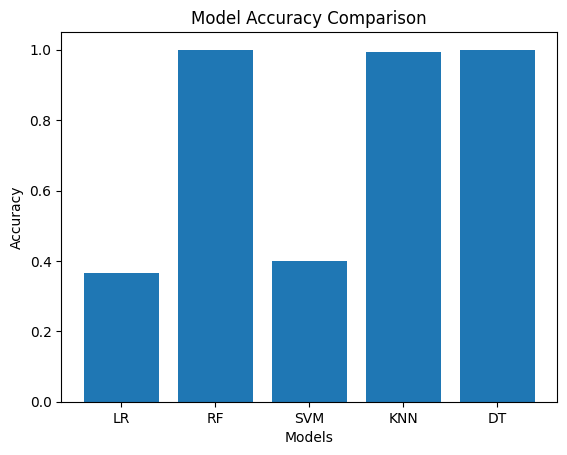

In [ ]:
accuracies = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_rf),
    accuracy_score(y_test, y_pred_svm),
    accuracy_score(y_test, y_pred_knn),
    accuracy_score(y_test, y_pred_dt)
]

models = ["LR", "RF", "SVM", "KNN", "DT"]

plt.figure()
plt.bar(models, accuracies)
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

In [ ]:
best_model = models[np.argmax(accuracies)]
best_accuracy = max(accuracies)

print("Best Model:", best_model)
print("Accuracy:", best_accuracy)

Best Model: RF
Accuracy: 1.0
